In [60]:
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

In [61]:
df = pd.read_csv('cardio_data_processed.csv')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,Hypertension Stage 1,Hypertension Stage 1
68201,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,Hypertension Stage 2,Hypertension Stage 2
68202,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,Hypertension Stage 2,Hypertension Stage 2
68203,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,Hypertension Stage 1,Hypertension Stage 1


In [62]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000
mean,49972.410498,19462.667737,1.348625,164.372861,74.100688,126.434924,81.263925,1.363243,1.225174,0.087662,0.053134,0.803548,0.493688,52.823635,27.510513
std,28852.138290,2468.381854,0.476539,8.176756,14.288862,15.961685,9.143985,0.678080,0.571288,0.282805,0.224302,0.397317,0.499964,6.769909,6.026497
min,0.000000,10798.000000,1.000000,55.000000,11.000000,90.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,3.471784
25%,24991.000000,17656.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115
50%,50008.000000,19700.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.346494
75%,74878.000000,21323.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.116213
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,180.000000,120.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,298.666667


In [63]:
df.isna().sum()

id                     0
age                    0
gender                 0
height                 0
weight                 0
ap_hi                  0
ap_lo                  0
cholesterol            0
gluc                   0
smoke                  0
alco                   0
active                 0
cardio                 0
age_years              0
bmi                    0
bp_category            0
bp_category_encoded    0
dtype: int64

In [64]:
def calcul_age(row):
    return row['age'] / 365.25

In [65]:
df['age'] = df.apply(calcul_age, axis=1).round(1)  # calcul de l'âge en années et arrondi à une décimale

In [66]:
df['age'] = df['age'].round(0)
df['bmi'] = df['bmi'].round(1)

In [67]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0,50,22.0,Hypertension Stage 1,Hypertension Stage 1
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1,55,34.9,Hypertension Stage 2,Hypertension Stage 2
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1,51,23.5,Hypertension Stage 1,Hypertension Stage 1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1,48,28.7,Hypertension Stage 2,Hypertension Stage 2
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0,47,23.0,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0,52,26.9,Hypertension Stage 1,Hypertension Stage 1
68201,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1,61,50.5,Hypertension Stage 2,Hypertension Stage 2
68202,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1,52,31.4,Hypertension Stage 2,Hypertension Stage 2
68203,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1,61,27.1,Hypertension Stage 1,Hypertension Stage 1


In [68]:
df.columns.to_list()

['id',
 'age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'age_years',
 'bmi',
 'bp_category',
 'bp_category_encoded']

In [69]:
columns = ['age',
 'gender',
 'height',
 'weight',
 'ap_hi',
 'ap_lo',
 'cholesterol',
 'gluc',
 'smoke',
 'alco',
 'active',
 'cardio',
 'age_years',
 'bmi',
 'bp_category',
 'bp_category_encoded']

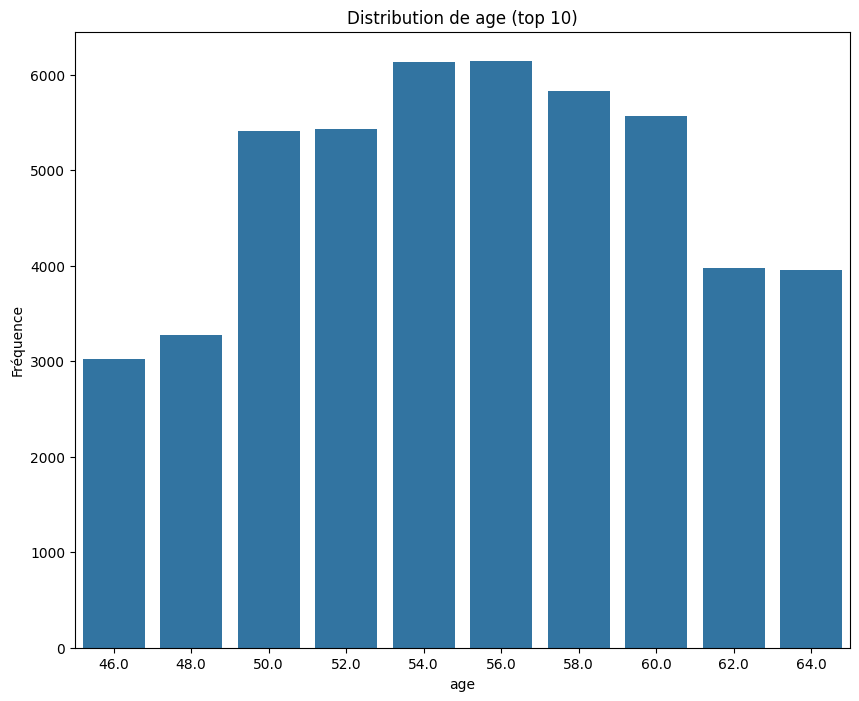

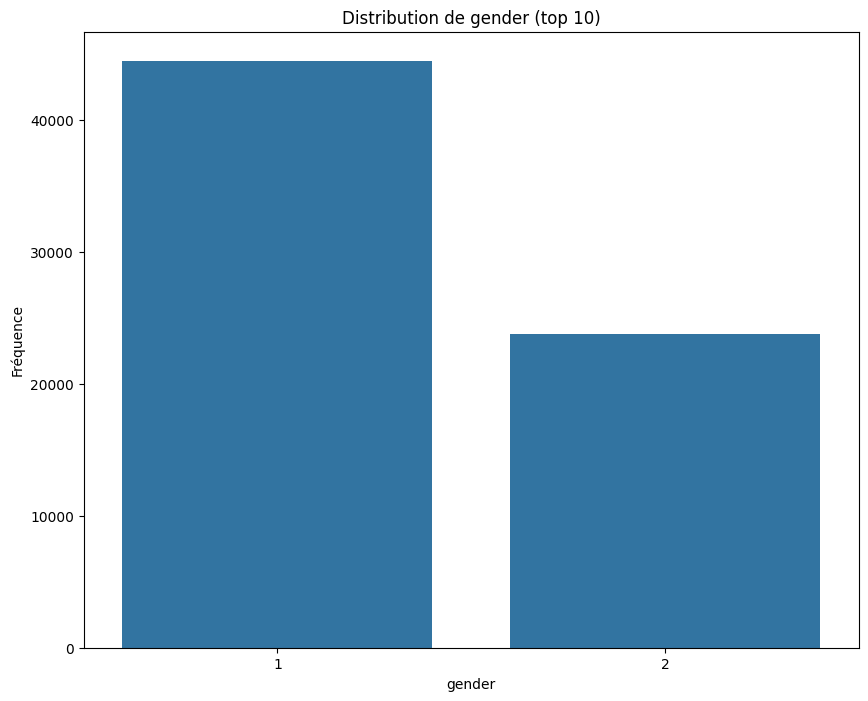

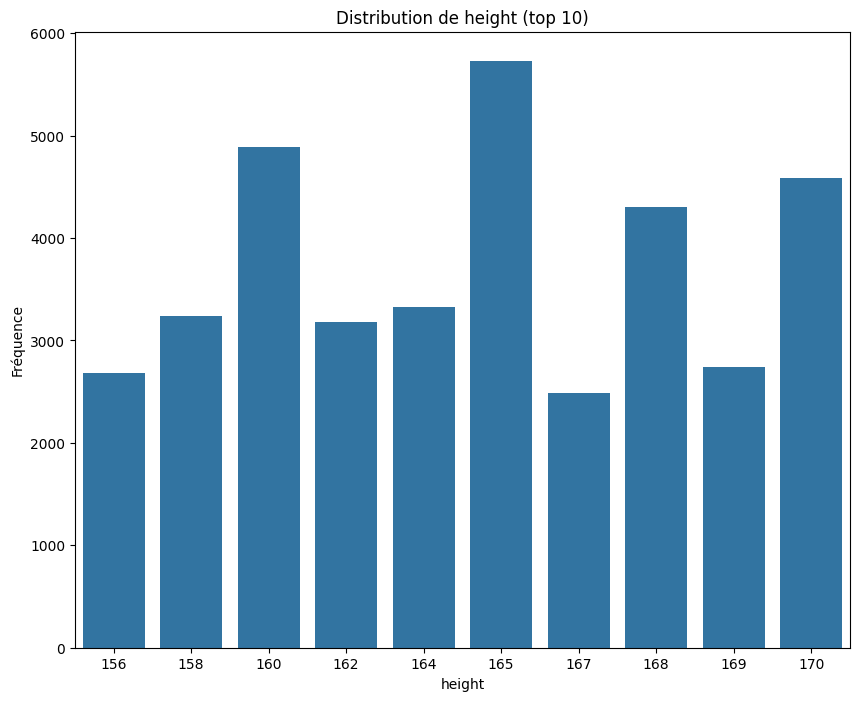

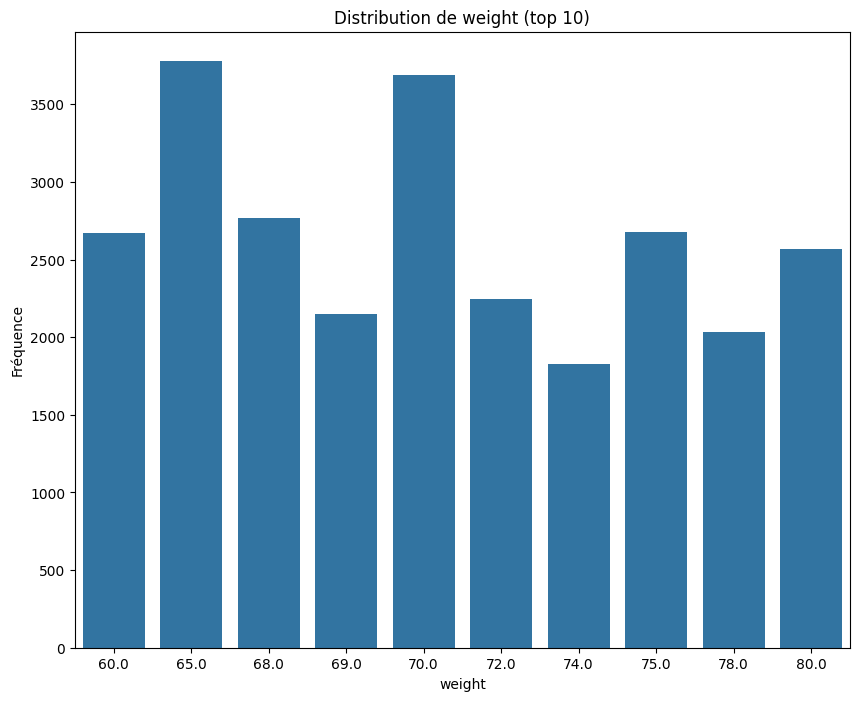

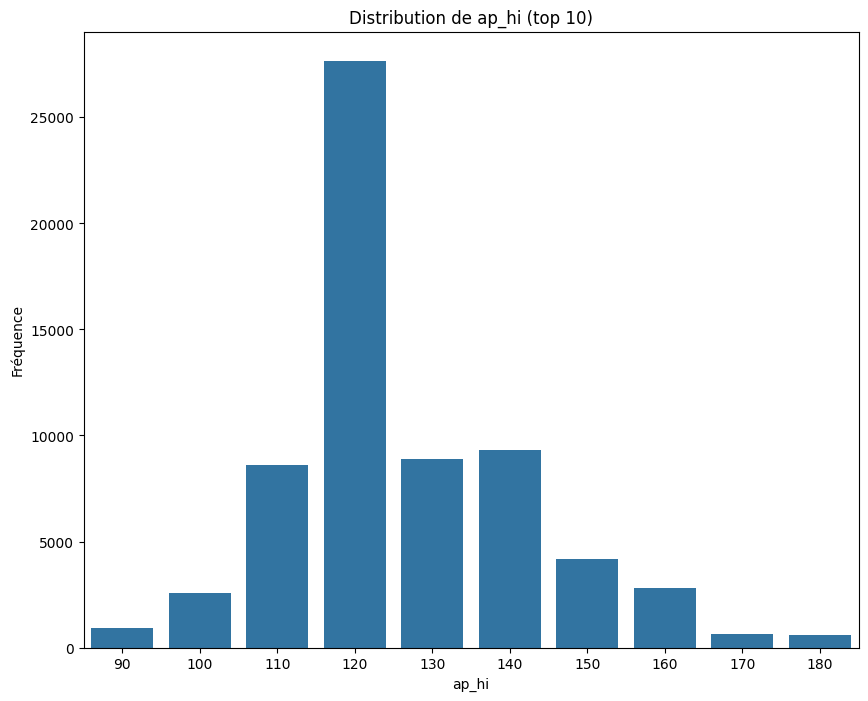

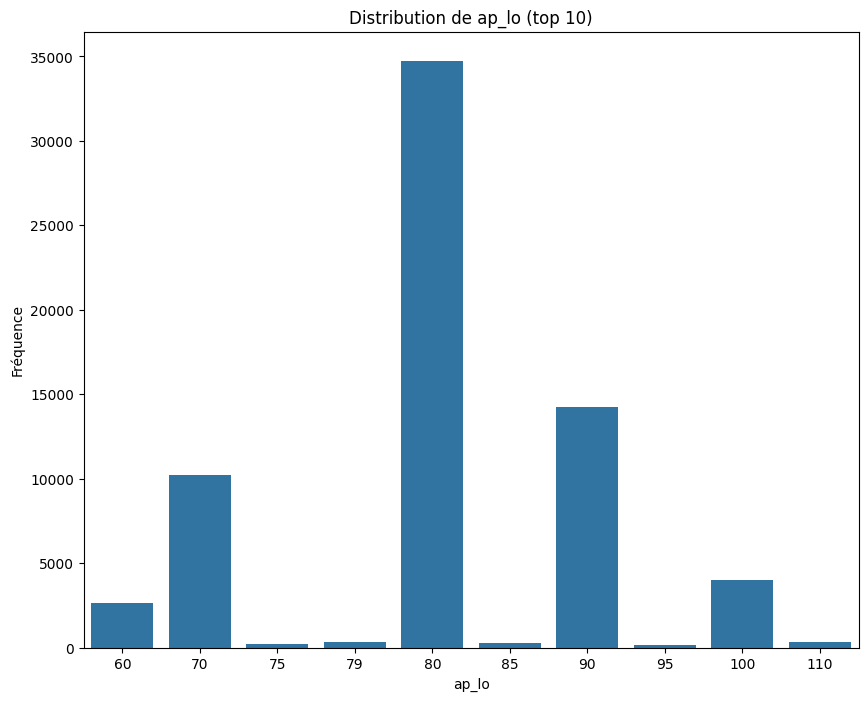

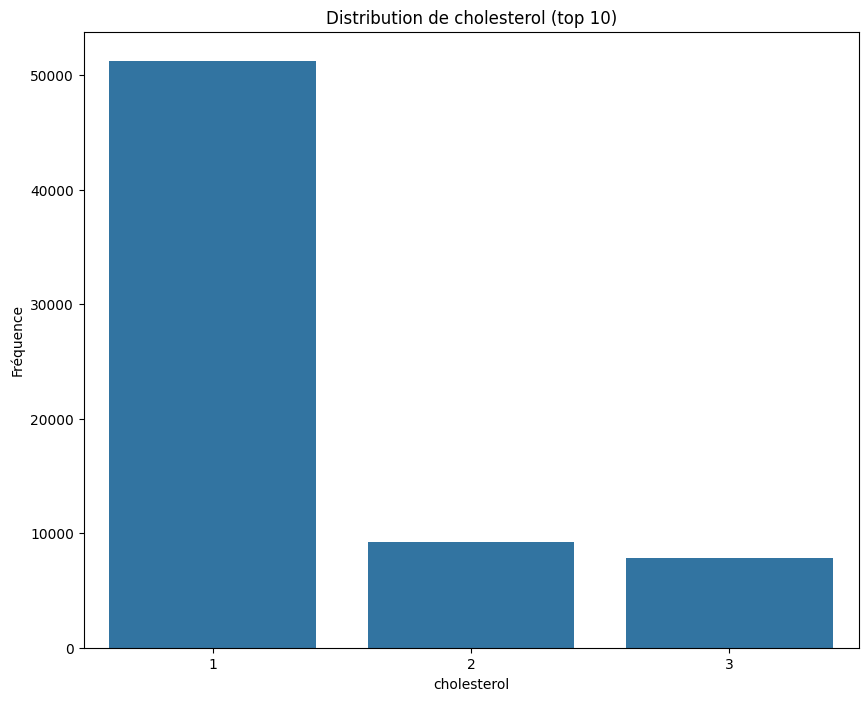

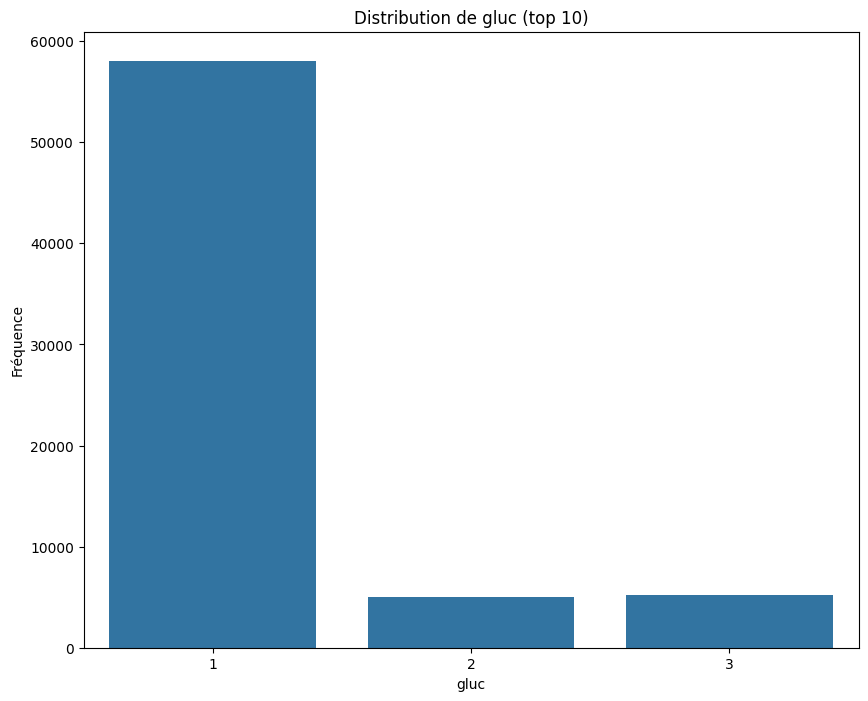

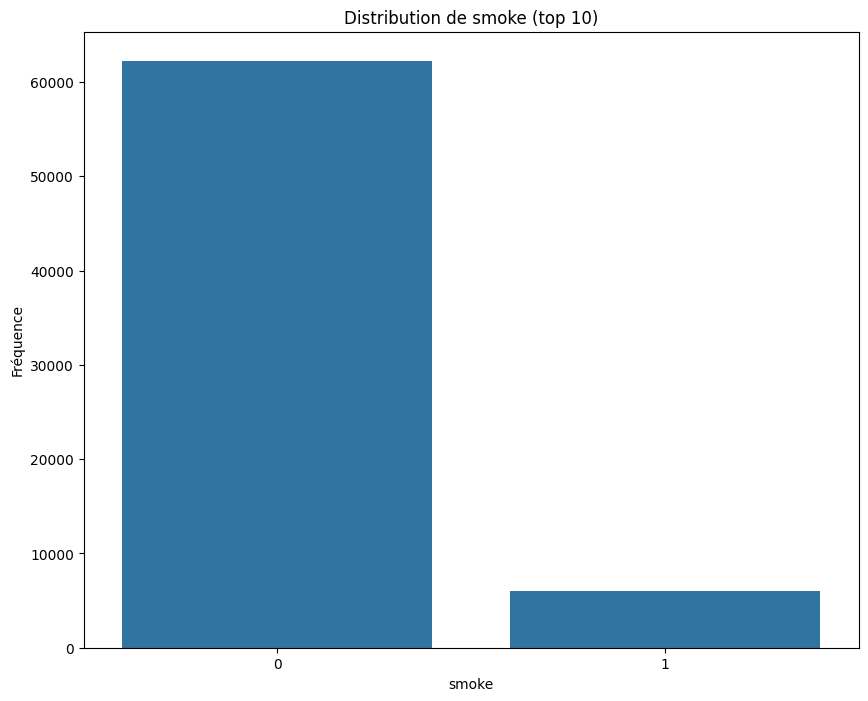

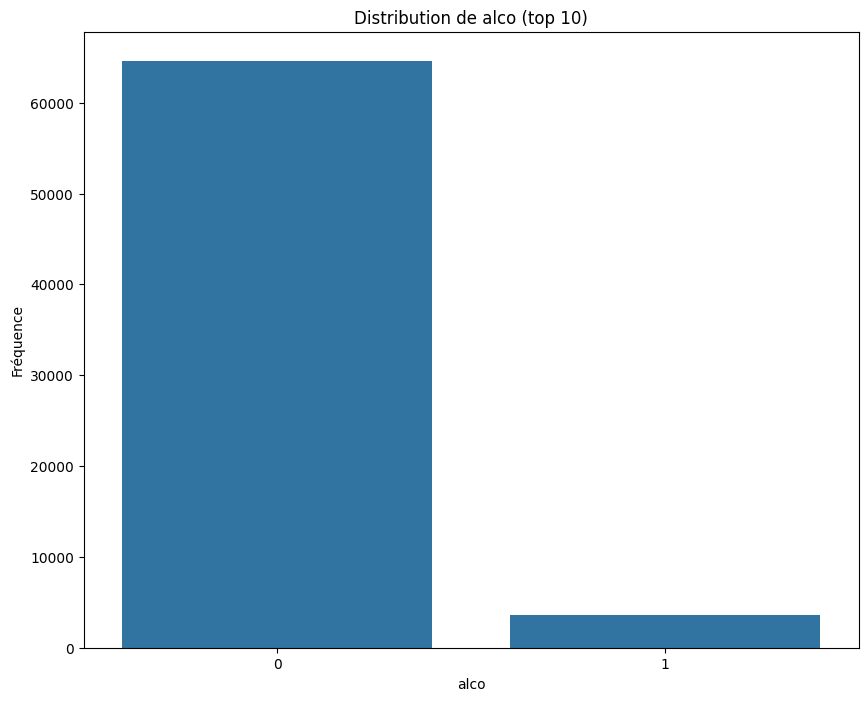

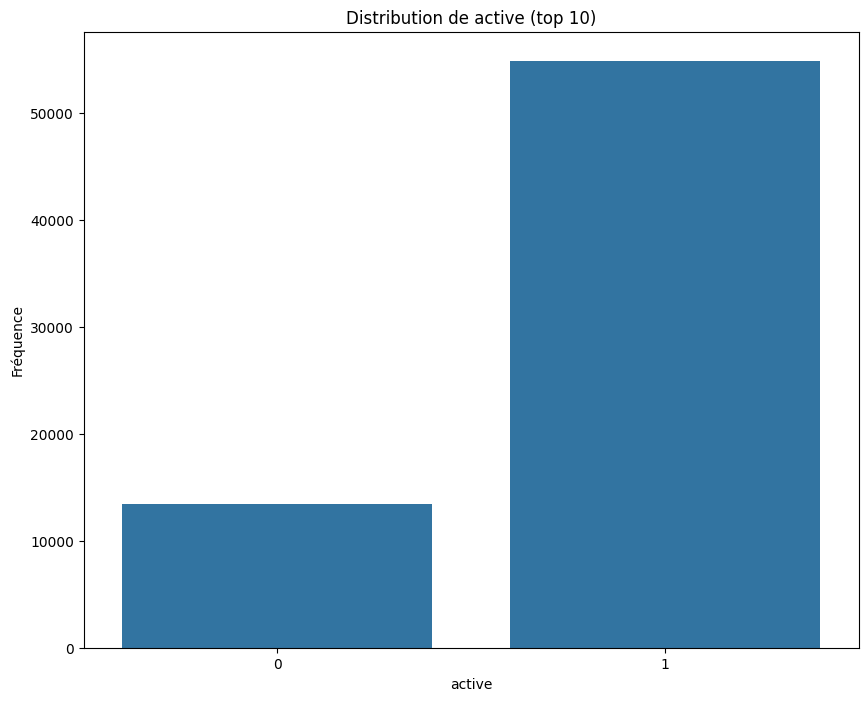

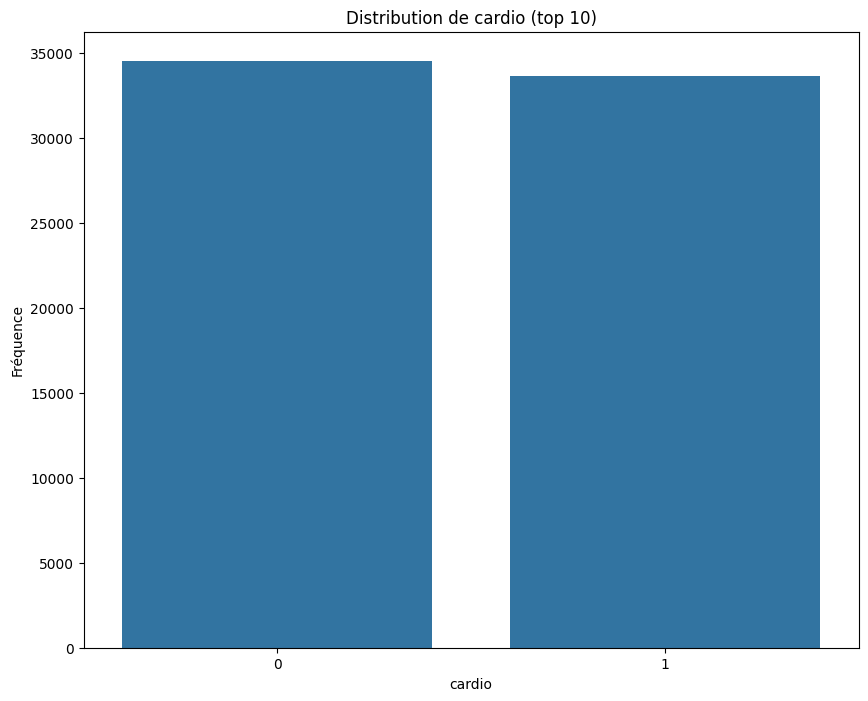

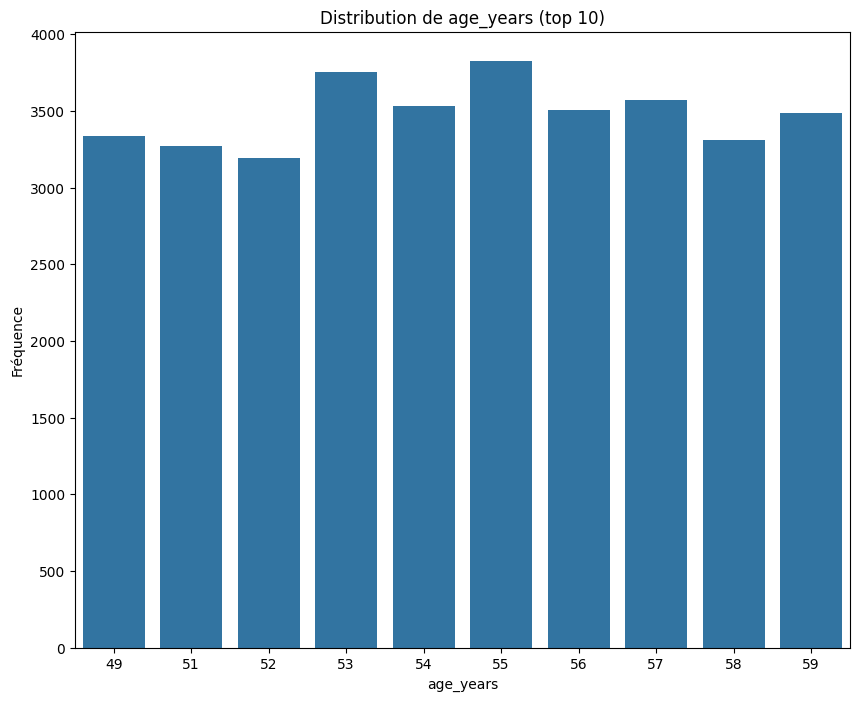

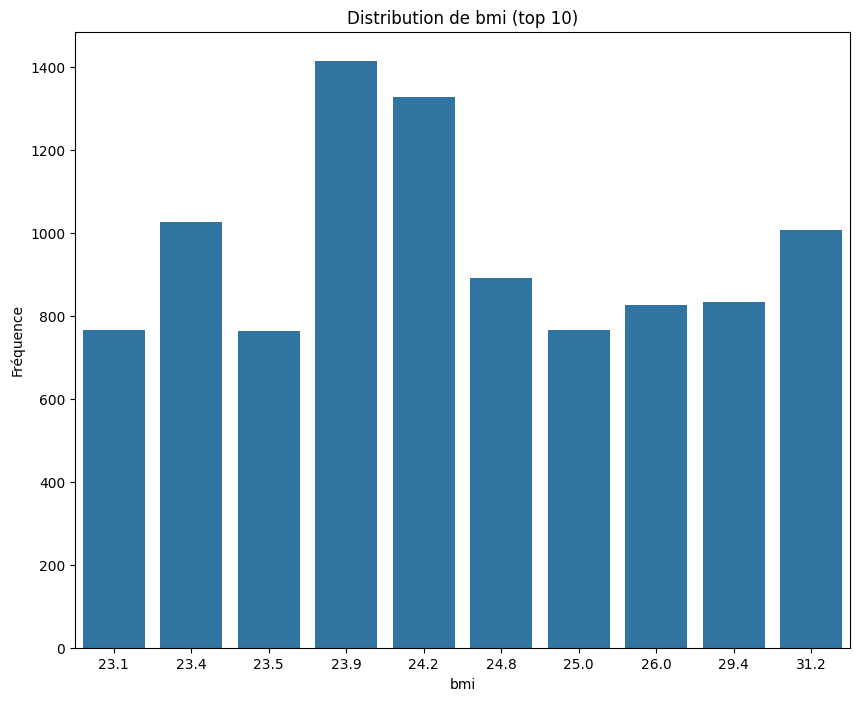

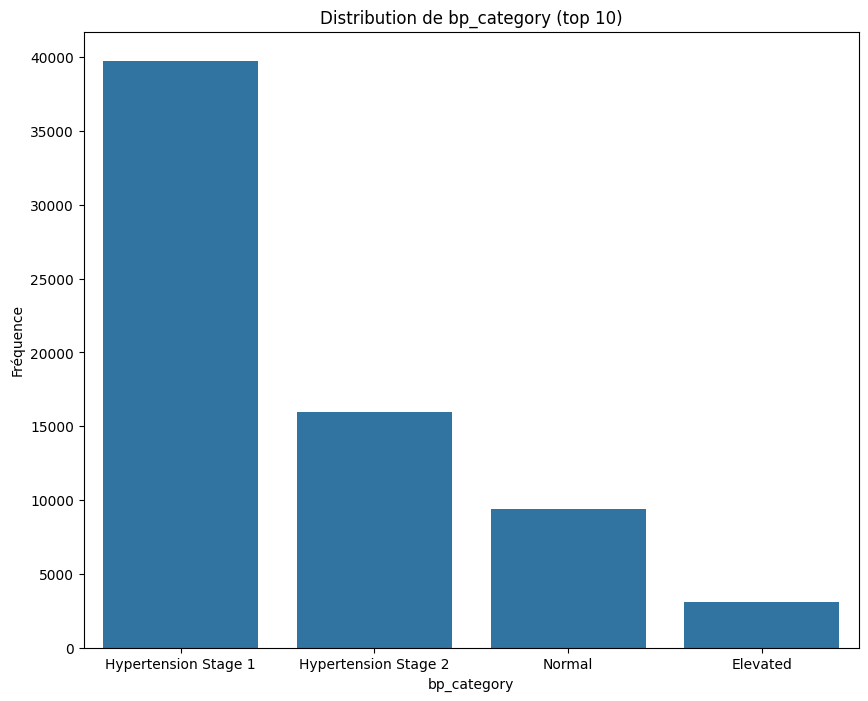

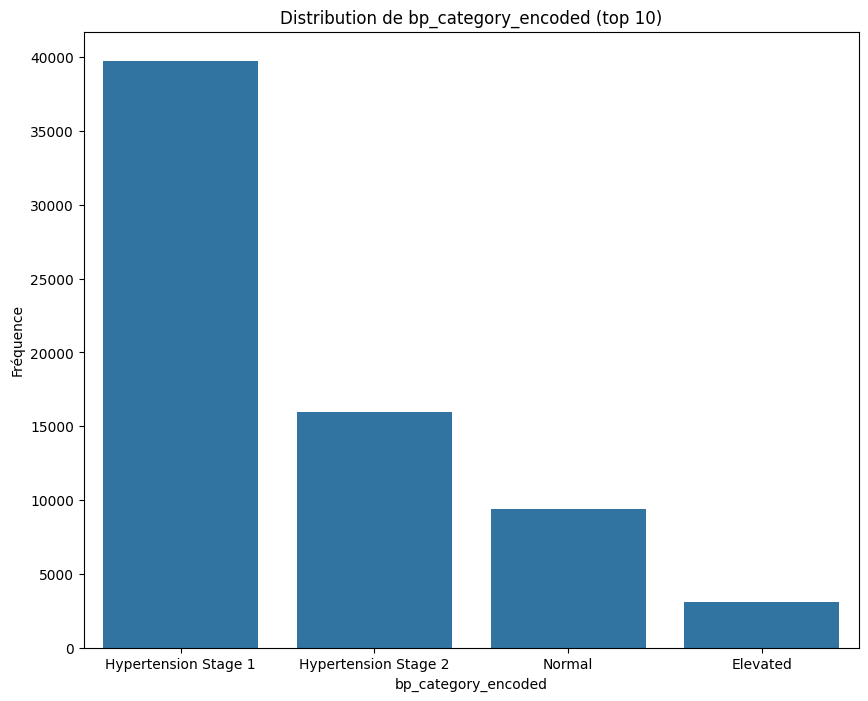

In [70]:
for col in columns:
    # calculer les 10 valeurs les plus fréquentes et leur fréquence
    freq = df[col].value_counts().head(10).sort_values(ascending=False)
    plt.figure(figsize=(10,8))
    sns.barplot(x=freq.index, y=freq.values)
    plt.title(f'Distribution de {col} (top 10)')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

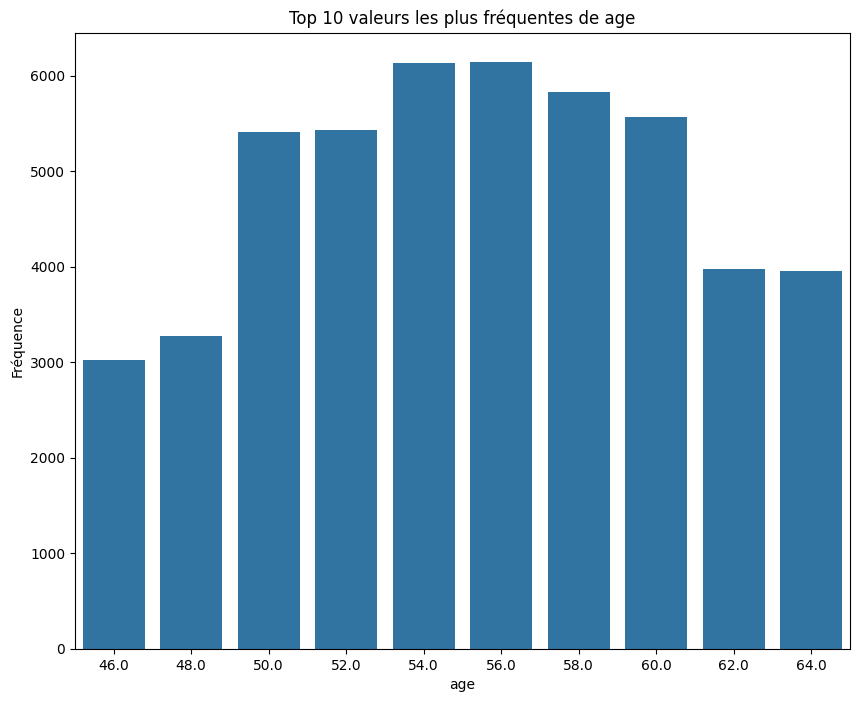

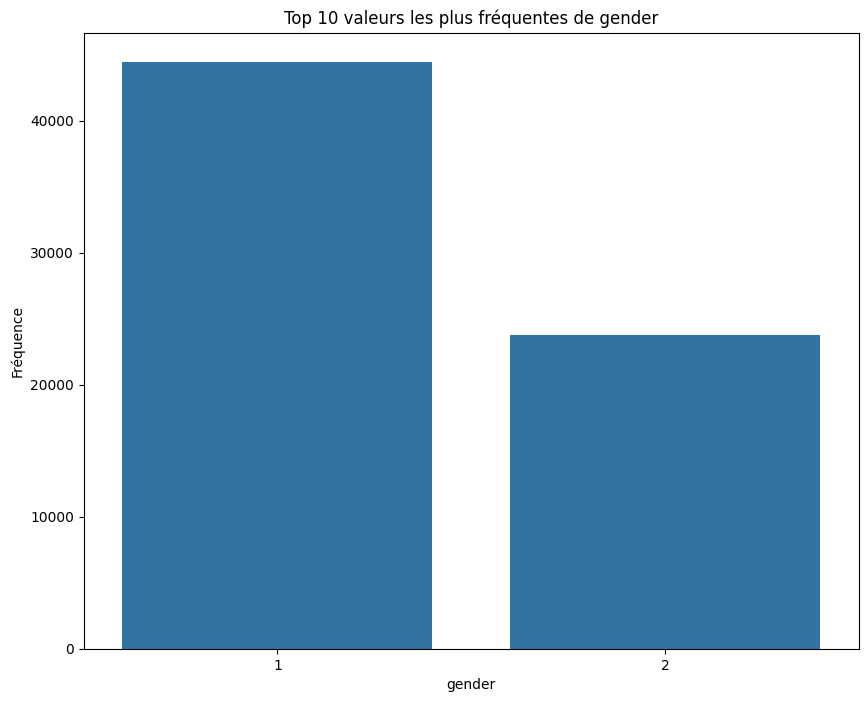

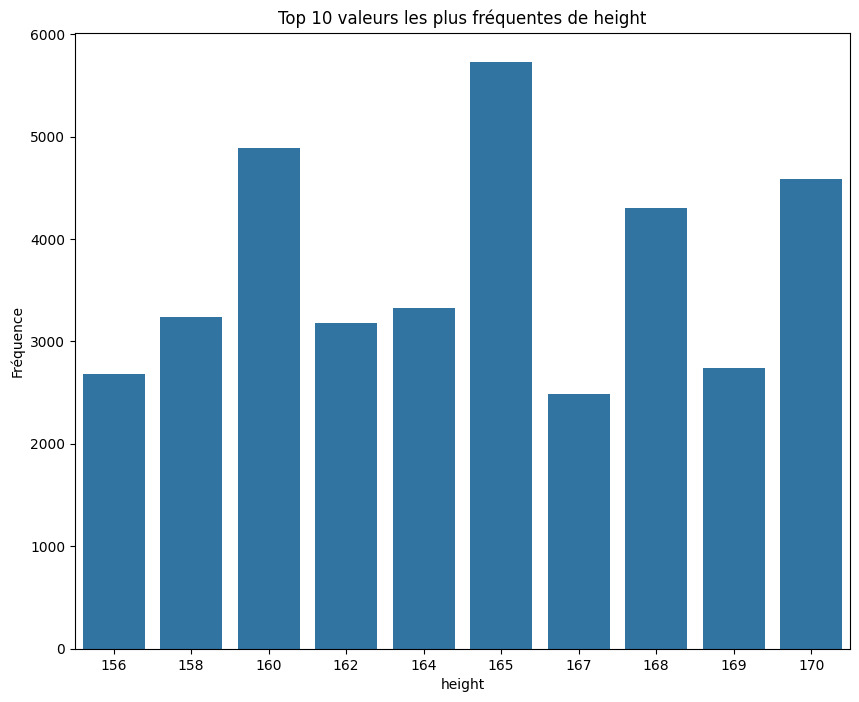

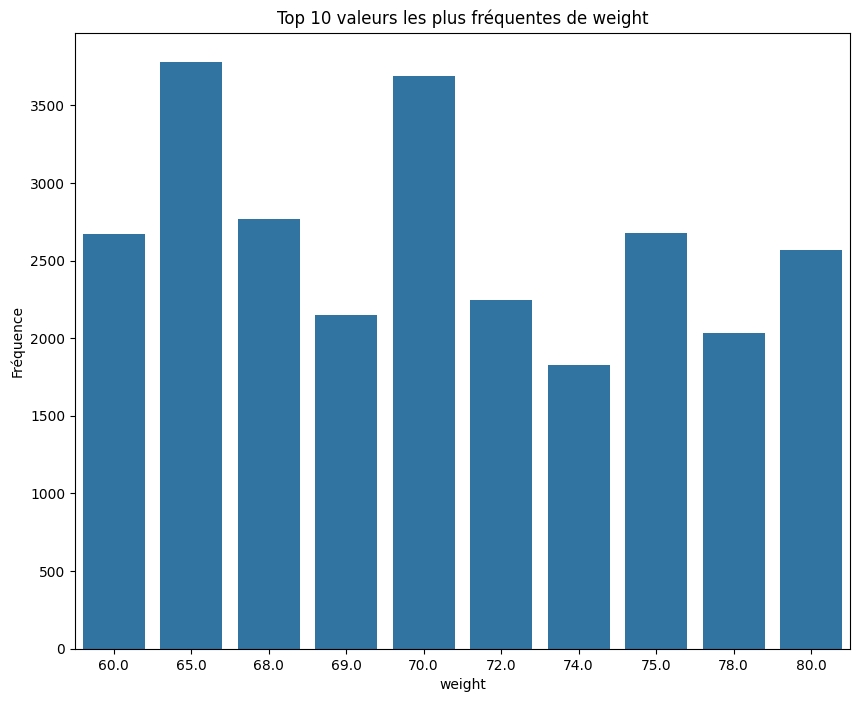

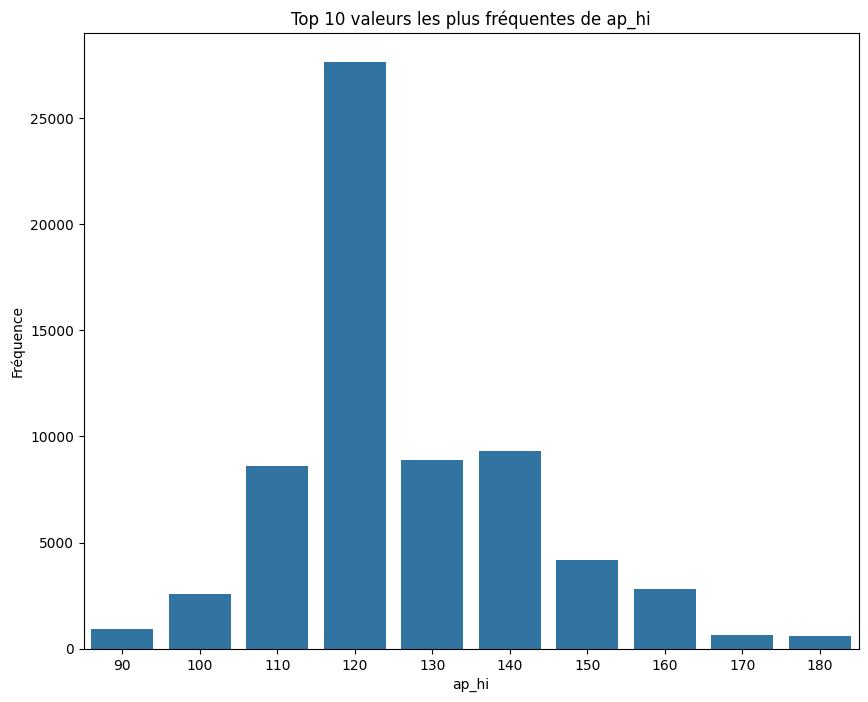

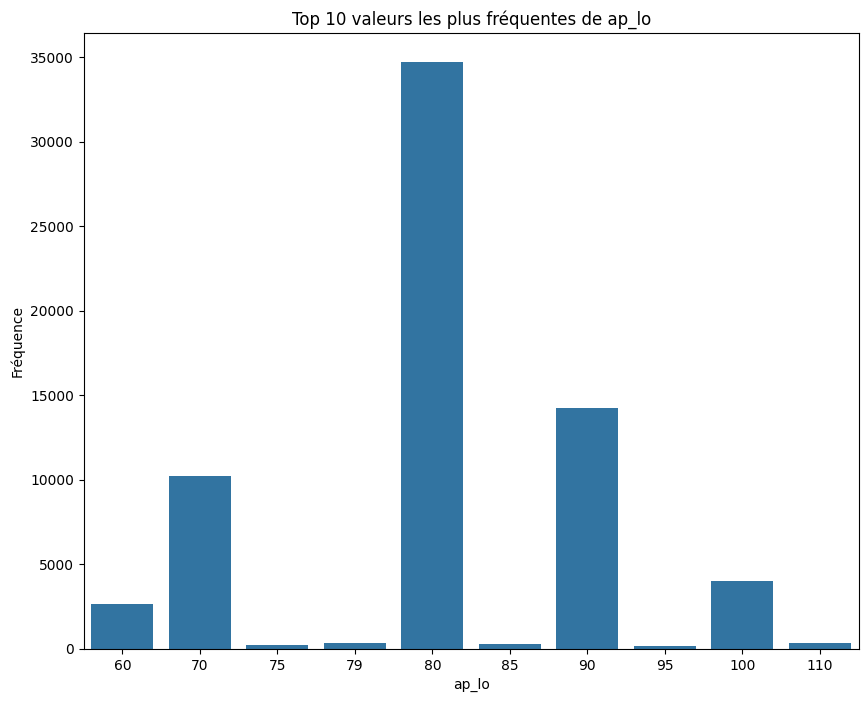

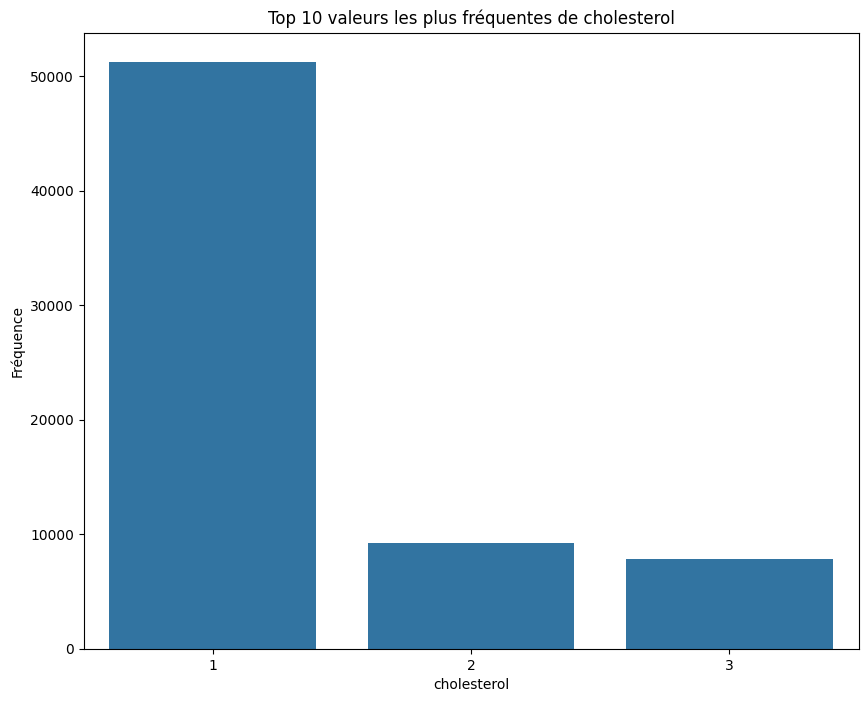

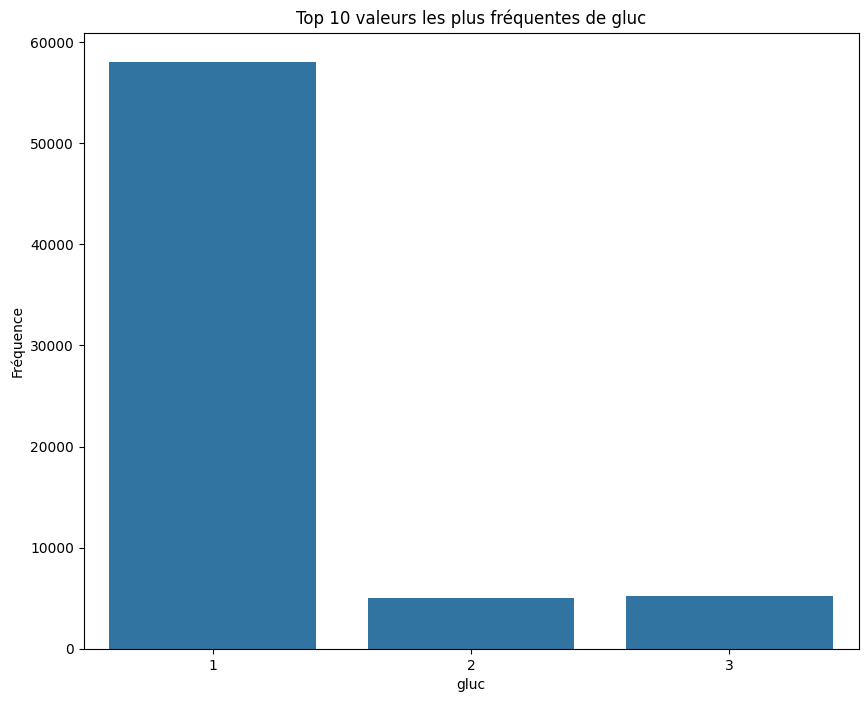

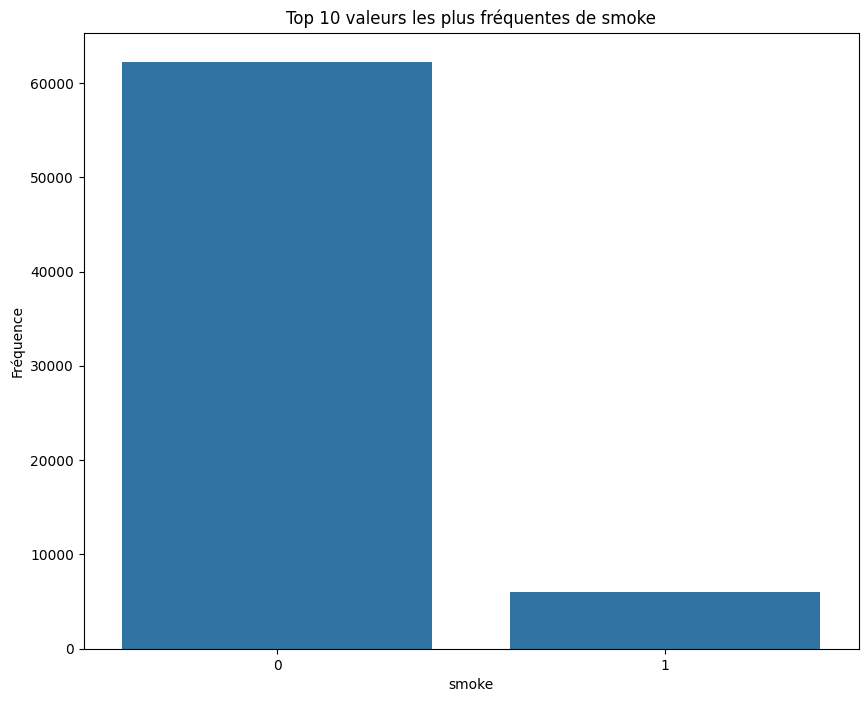

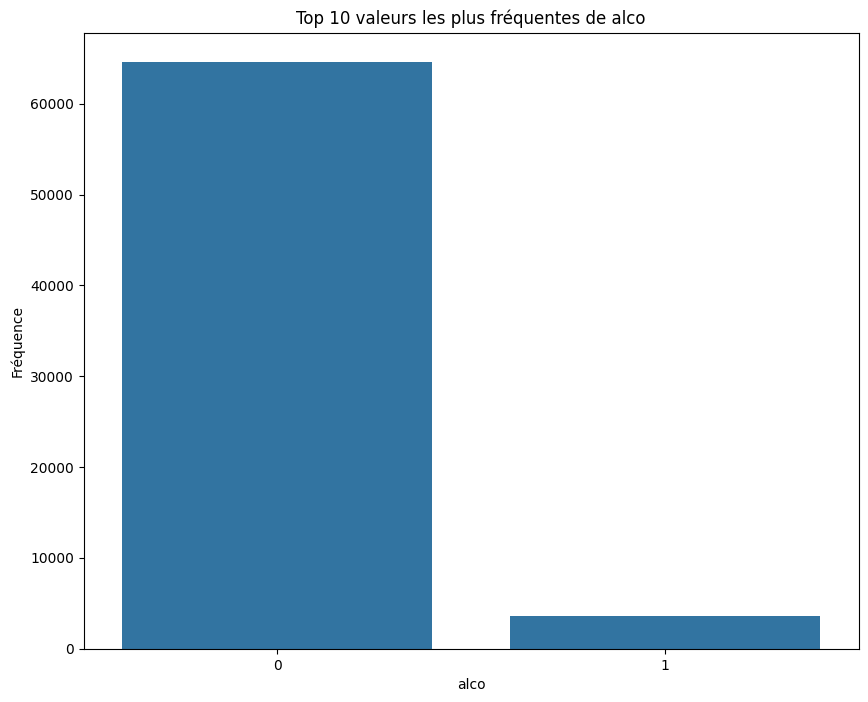

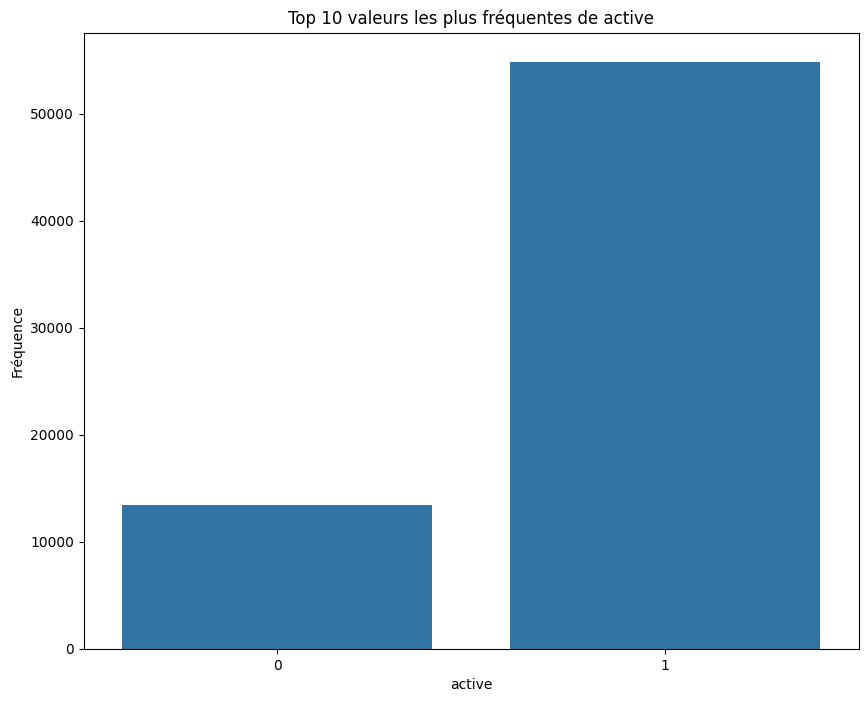

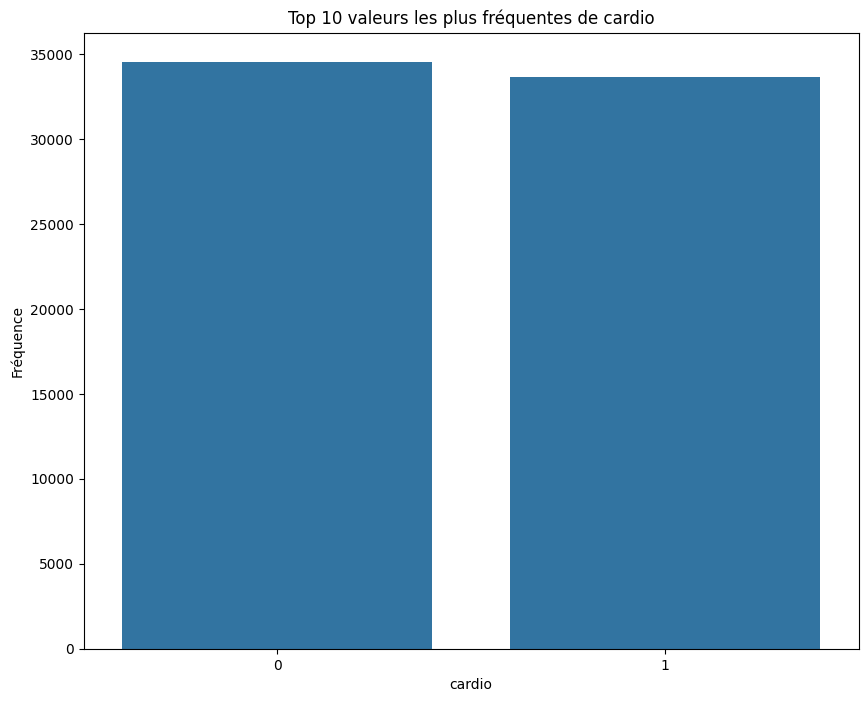

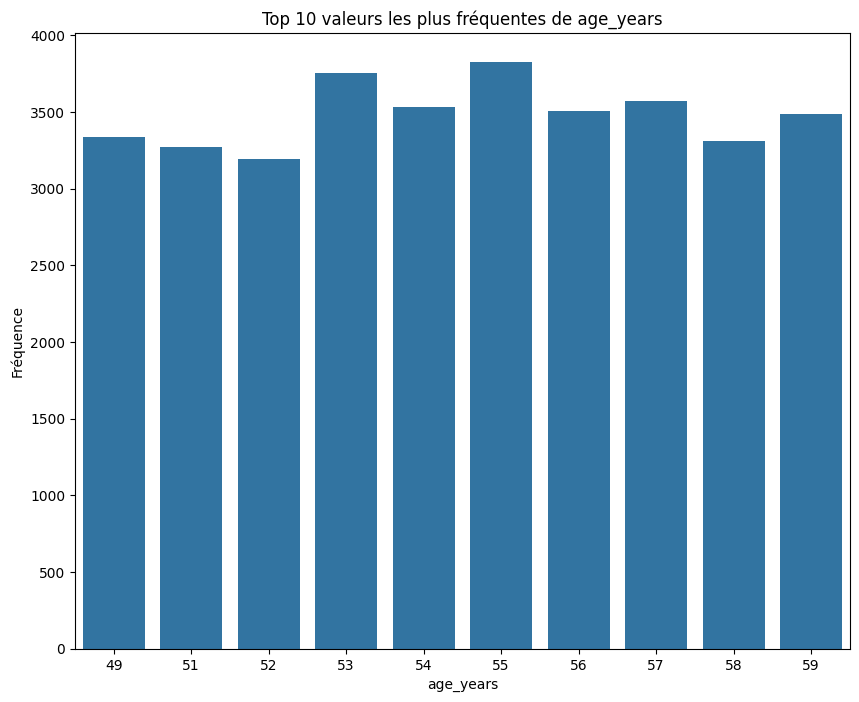

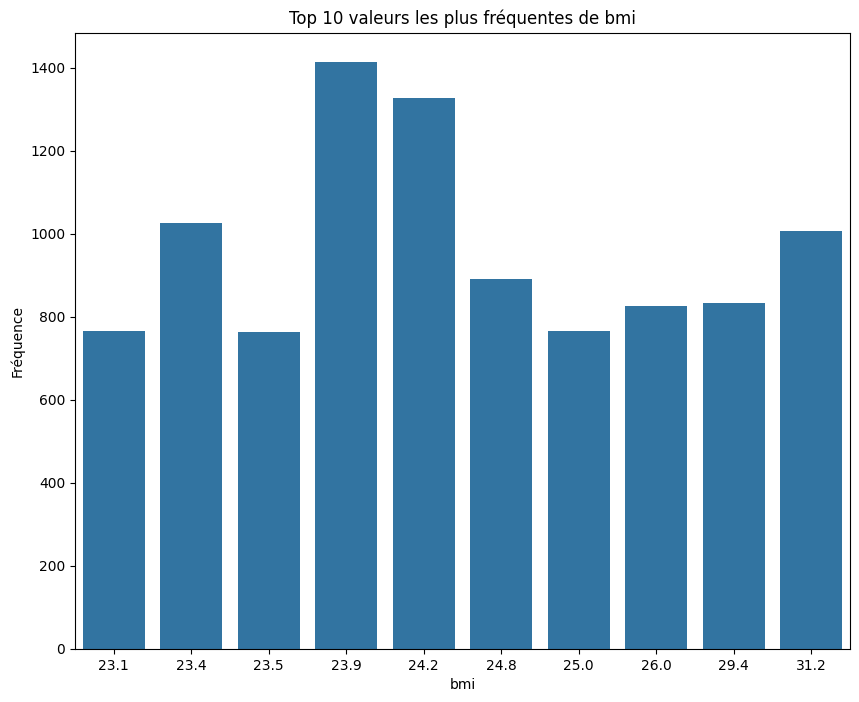

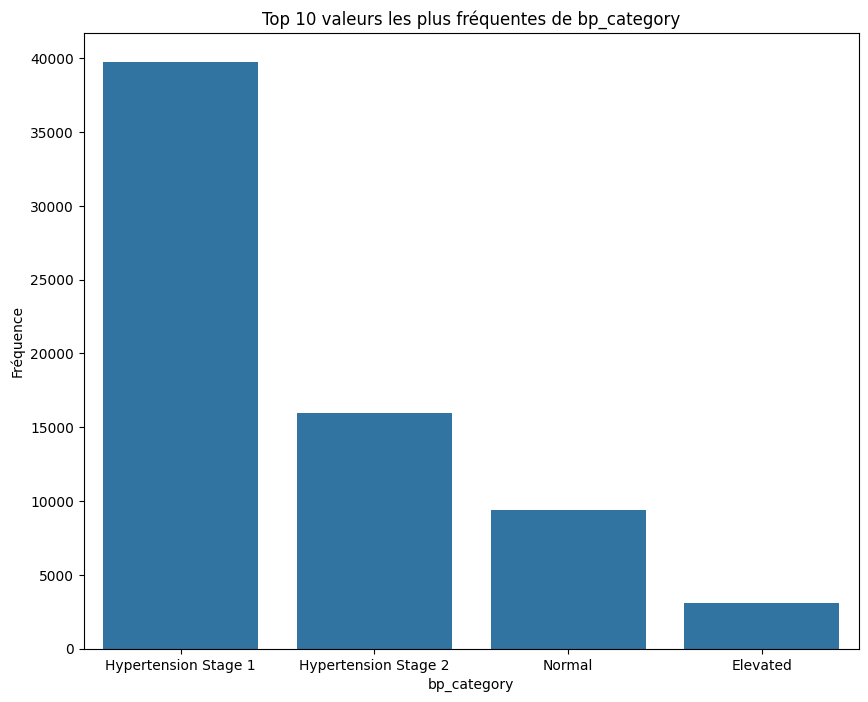

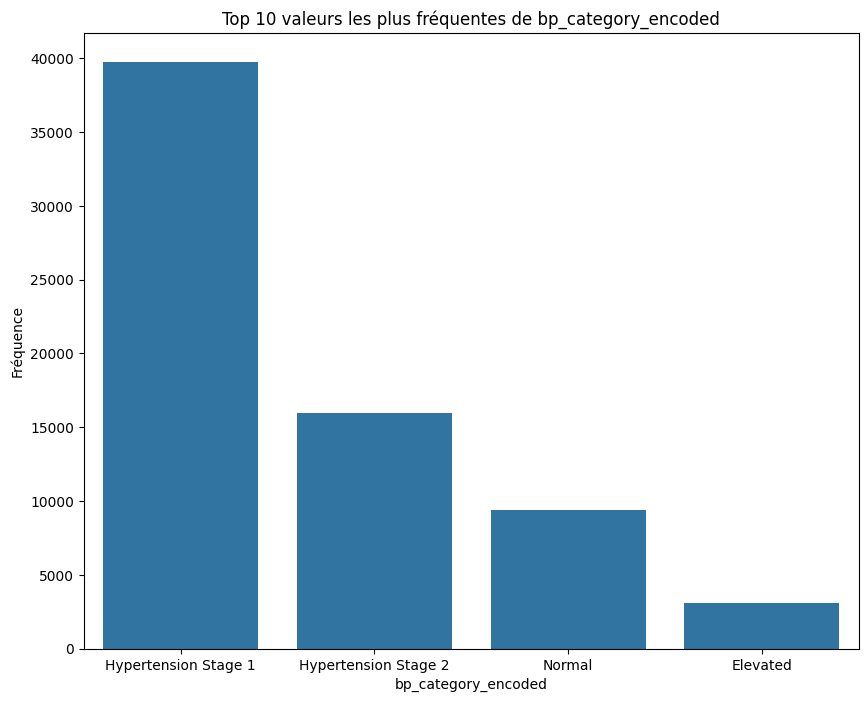

In [71]:
for col in columns:
    # récupérer les 10 valeurs les plus fréquentes dans la colonne
    freq = df[col].value_counts().head(10)
    # trier selon la fréquence en ordre croissant
    freq = freq.sort_values(ascending=False)
    plt.figure(figsize=(10,8))
    # axe x = valeurs, axe y = fréquences
    sns.barplot(x=freq.index, y=freq.values)
    plt.title(f"Top 10 valeurs les plus fréquentes de {col}")
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

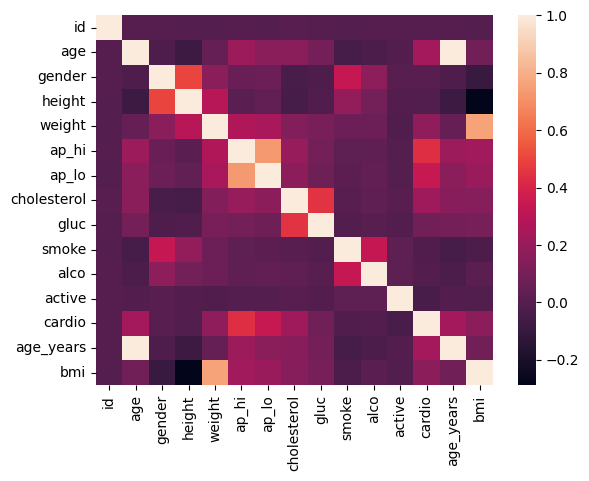

In [72]:
df_number = df.select_dtypes('number')
corr = df_number.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

<Axes: xlabel='cardio'>

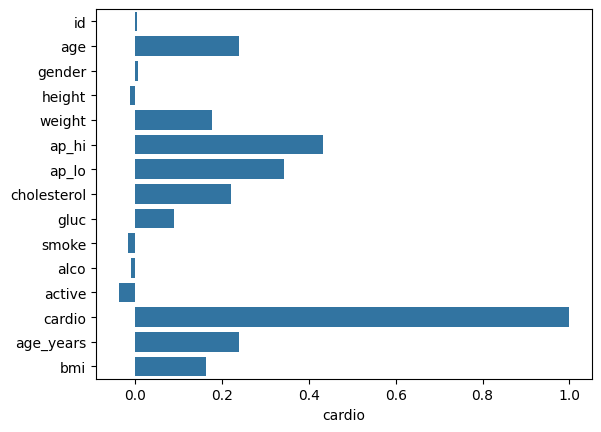

In [73]:
sns.barplot(df_number.corr().loc["cardio"], orient="y")

In [74]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0,50,22.0,Hypertension Stage 1,Hypertension Stage 1
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1,55,34.9,Hypertension Stage 2,Hypertension Stage 2
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1,51,23.5,Hypertension Stage 1,Hypertension Stage 1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1,48,28.7,Hypertension Stage 2,Hypertension Stage 2
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0,47,23.0,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0,52,26.9,Hypertension Stage 1,Hypertension Stage 1
68201,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1,61,50.5,Hypertension Stage 2,Hypertension Stage 2
68202,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1,52,31.4,Hypertension Stage 2,Hypertension Stage 2
68203,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1,61,27.1,Hypertension Stage 1,Hypertension Stage 1


In [75]:
df_enc = pd.get_dummies(df, columns=['gender','gluc','smoke','active','alco','cholesterol','bp_category'])


In [77]:
df_enc

,id,age,height,weight,ap_hi,ap_lo,cardio,age_years,bmi,bp_category_encoded,...,active_1,alco_0,alco_1,cholesterol_1,cholesterol_2,cholesterol_3,bp_category_Elevated,bp_category_Hypertension Stage 1,bp_category_Hypertension Stage 2,bp_category_Normal
0,0,50.0,168,62.0,110,80,0,50,22.0,Hypertension Stage 1,...,True,True,False,True,False,False,False,True,False,False
1,1,55.0,156,85.0,140,90,1,55,34.9,Hypertension Stage 2,...,True,True,False,False,False,True,False,False,True,False
2,2,52.0,165,64.0,130,70,1,51,23.5,Hypertension Stage 1,...,False,True,False,False,False,True,False,True,False,False
3,3,48.0,169,82.0,150,100,1,48,28.7,Hypertension Stage 2,...,True,True,False,True,False,False,False,False,True,False
4,4,48.0,156,56.0,100,60,0,47,23.0,Normal,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,99993,53.0,168,76.0,120,80,0,52,26.9,Hypertension Stage 1,...,True,True,False,True,False,False,False,True,False,False
68201,99995,62.0,158,126.0,140,90,1,61,50.5,Hypertension Stage 2,...,True,True,False,False,True,False,False,False,True,False
68202,99996,52.0,183,105.0,180,90,1,52,31.4,Hypertension Stage 2,...,False,False,True,False,False,True,False,False,True,False
68203,99998,61.0,163,72.0,135,80,1,61,27.1,Hypertension Stage 1,...,False,True,False,True,False,False,False,True,False,False


In [78]:
df_enc = df_enc.drop(columns=['id', 'bp_category_encoded','cardio'])

In [79]:
df_enc

,age,height,weight,ap_hi,ap_lo,age_years,bmi,gender_1,gender_2,gluc_1,...,active_1,alco_0,alco_1,cholesterol_1,cholesterol_2,cholesterol_3,bp_category_Elevated,bp_category_Hypertension Stage 1,bp_category_Hypertension Stage 2,bp_category_Normal
0,50.0,168,62.0,110,80,50,22.0,False,True,True,...,True,True,False,True,False,False,False,True,False,False
1,55.0,156,85.0,140,90,55,34.9,True,False,True,...,True,True,False,False,False,True,False,False,True,False
2,52.0,165,64.0,130,70,51,23.5,True,False,True,...,False,True,False,False,False,True,False,True,False,False
3,48.0,169,82.0,150,100,48,28.7,False,True,True,...,True,True,False,True,False,False,False,False,True,False
4,48.0,156,56.0,100,60,47,23.0,True,False,True,...,False,True,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68200,53.0,168,76.0,120,80,52,26.9,False,True,True,...,True,True,False,True,False,False,False,True,False,False
68201,62.0,158,126.0,140,90,61,50.5,True,False,False,...,True,True,False,False,True,False,False,False,True,False
68202,52.0,183,105.0,180,90,52,31.4,False,True,True,...,False,False,True,False,False,True,False,False,True,False
68203,61.0,163,72.0,135,80,61,27.1,True,False,False,...,False,True,False,True,False,False,False,True,False,False


In [80]:
y = df['cardio']
X = df_enc


In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.80, random_state=36)

In [82]:
X_test.shape

(54564, 25)

In [83]:
y_test.shape

(54564,)

In [84]:
model = LogisticRegression(random_state=36)

In [85]:
a = model.fit(X_train,y_train)

C:\Users\Anisa ABDULLAHI ABDI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [86]:
a.score(X_test,y_test)

0.7238472252767393

In [87]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 1, 1], shape=(54564,))

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [90]:
resultat = accuracy_score(y_test,y_pred)
resultat

0.7238472252767393

In [92]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[22299,  5288],
       [ 9780, 17197]])

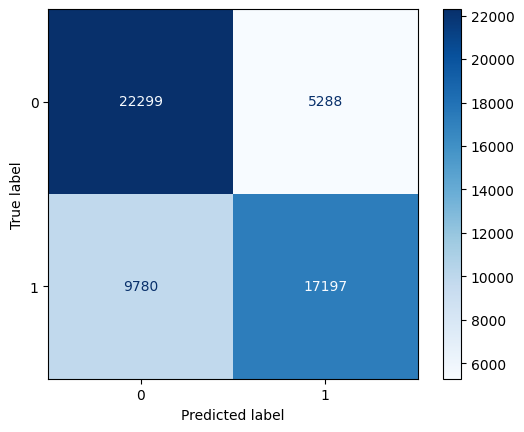

In [93]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [94]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.81      0.75     27587
           1       0.76      0.64      0.70     26977

    accuracy                           0.72     54564
   macro avg       0.73      0.72      0.72     54564
weighted avg       0.73      0.72      0.72     54564

